## **Aprendizado Bayesiano**

Dado um conjunto de dados $D$ e um espaço de hipóteses $H$, queremos é inferir a hipótese mais provável $h$ dado $D$.

### **Teorema de Bayes**

O núcleo desse processo é dado por:

$$
P(h \mid D) = \dfrac{P(D \mid h)\,P(h)}{P(D)}
$$

onde:

* $P(h)$ é a probabilidade a priori da hipótese $h$, antes de observar $D$
* $P(D \mid h)$ é a verossimilhança: a probabilidade de observar $D$ dada a hipótese $h$
* $P(D)$ é a evidência (ou constante de normalização)
* $P(h \mid D)$ é a probabilidade a posteriori da hipótese $h$, após observar $D$

### **Forma utilizada na prática**

Como $P(D)$ é constante para todas as classes, utilizamos:

$$
P(h \mid D) \propto P(D \mid h)\,P(h)
$$

E a decisão é feita por:

$$
h_{MAP} = \arg\max_{h \in H} P(D \mid h)\,P(h)
$$

Esse critério de decisão é conhecido como **Maximum a Posteriori (MAP)**.

### **Classificador Naive Bayes**

Dado um espaço de instâncias $X$ e um conjunto de classes $C$, para $\mathbf{x} \in X$, queremos prever a classe $c$ mais provável dado $\mathbf{x}$.

Utilizando o critério **MAP**, temos:

$$
\hat{c} = \arg\max_{c \in C} P(\mathbf{x} \mid c)\,P(c)
$$

No contexto de classificação, cada hipótese $h$ corresponde a uma classe $c$, ou seja, $h \equiv c$.

#### **Hipótese de Naive Bayes**

Assumimos que as features são independentes dado a classe:

$$
P(x_1, x_2, x_3, \dots, x_n \mid c) = \prod_{i=1}^{n}P(x_i \mid c)
$$

#### **Modelo Probabilístico**

Modelamos então probabilidade de uma amostra $\mathbf{x} = (x_1, x_2, x_3, \dots, x_n)$ ser da classe $c$ como:

$$
P(c \mid \mathbf{x}) \propto P(c)\prod_{i=1}^{n}P(x_i \mid c)
$$

#### **Decisão da classe**

A predição é feita escolhendo a classe que maximiza a probabilidade posterior:

$$
\hat{c} = \arg\max_{c \in C} P(c)\prod_{i=1}^{n}P(x_i \mid c)
$$

#### **Aplicação do logaritmo**

Como as probabilidades condicionais são tipicamente muito pequenas,

$$
P(x_i \mid c) \ll 1
$$

o produto dessas probabilidades pode rapidamente tender a zero:

$$
\prod_{i=1}^{n} P(x_i \mid c) \rightarrow 0
$$

causando problemas de underflow numérico.

Para contornar isso, aplicamos o logaritmo, que transforma produtos em somas e melhora a estabilidade numérica:

$$
\hat{c} = \arg\max_{c \in C} \left[ \log P(c) + \sum_{i=1}^{n} \log P(x_i \mid c) \right]
$$

Como o logaritmo é uma função monotonicamente crescente, ele não altera o resultado do $\arg\max$.

#### **Gaussian Naive Bayes**

Neste modelo, assumimos que, para cada classe $c$ e cada feature $x_i$, temos:

$$
x_i \mid c \sim \mathcal{N}(\mu_{c,i}, \sigma_{c,i}^{2})
$$

Logo, a verossimilhança de uma única feature é:

$$
P(x_i \mid c) = \frac{1}{\sqrt{2\pi\sigma_{c,i}^{2}}}
\exp\left(-\frac{(x_i - \mu_{c,i})^2}{2\sigma_{c,i}^{2}}\right)
$$

Os parâmetros das distribuições Gaussianas são estimados a partir dos dados de treino:

$$
\mu_{c,i} = \frac{1}{N_c} \sum_{\mathbf{x} \in D_c} x_i
\quad\quad
\sigma_{c,i}^2 = \frac{1}{N_c} \sum_{\mathbf{x} \in D_c} (x_i - \mu_{c,i})^2
$$

onde $N_c = |D_c|$ é o número de exemplos da classe $c$, e $D_c = \{ \mathbf{x} \in D \mid \mathbf{x} \text{ pertence à classe } c \}$.

> FACELI, Katti; LORENA, Ana Carolina; GAMA, João; CARVALHO, André C. P. L. F. de. Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina. Rio de Janeiro: LTC, 2011. Seção 5.1, p. 71.

> GOODFELLOW, Ian; BENGIO, Yoshua; COURVILLE, Aaron. Deep Learning. Cambridge: MIT Press, 2016. Seção 5.6, p. 67.

> BISHOP, Christopher M. Pattern Recognition and Machine Learning. New York: Springer, 2006. Seção 1.2.3, p. 21 e Seção 1.2.4, p. 24.

## **Implementação do Naive Bayes para problema de Classificação**

Vamos utilizar **Gaussian Naive Bayes** para tarefa de **classificação**  no dataset [**Iris Flower Dataset**](https://scikit-learn.org/1.5/auto_examples/datasets/plot_iris_dataset.html).

### **Pré-processamento dos dados**

#### **Dataset**

In [39]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (150, 4)
Shape de y: (150,)


In [40]:
import pandas as pd

df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y

df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [41]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


#### **Divisão do dataset em conjuntos de treino e validação**

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (120, 4)
Teste: (30, 4)


### **Implementação do Gaussian Neive Bayes**

#### **Cálculo das Médias, Variâncias e Priors de cada classe**

In [43]:
import numpy as np

def train(X_train, y_train):
    classes = np.unique(y_train)

    means = dict()
    vars_ = dict()
    priors = dict()

    for c in classes:
        X_c = X_train[y_train == c]

        means[c] = X_c.mean(axis=0)
        vars_[c] = X_c.var(axis=0)
        priors[c] = len(X_c) / len(X_train)

    return classes, means, vars_, priors

#### **Verosimilhança**

In [44]:
def gaussian(x, mean, var):
    coeff = 1 / np.sqrt(2 * np.pi * var)
    exponent = np.exp(-(x - mean)**2 / (2 * var))
    return coeff * exponent

### **Treinamento e Validação**

#### **Treinamento**

In [45]:
classes, means, vars_, priors = train(X_train, y_train)

#### **Validação**

In [46]:
def predict(X, classes, means, vars_, priors):
    predictions = []

    for x in X:
        posteriors = []

        for c in classes:
            log_prior = np.log(priors[c])

            log_likelihood = 0
            for i in range(len(x)):
                prob = gaussian(x[i], means[c][i], vars_[c][i])
                log_likelihood += np.log(prob)

            posterior = log_prior + log_likelihood
            posteriors.append(posterior)

        predictions.append(np.argmax(posteriors))

    return np.array(predictions)

In [47]:
y_pred = predict(X_test, classes, means, vars_, priors)

#### **Matriz de Confusão**

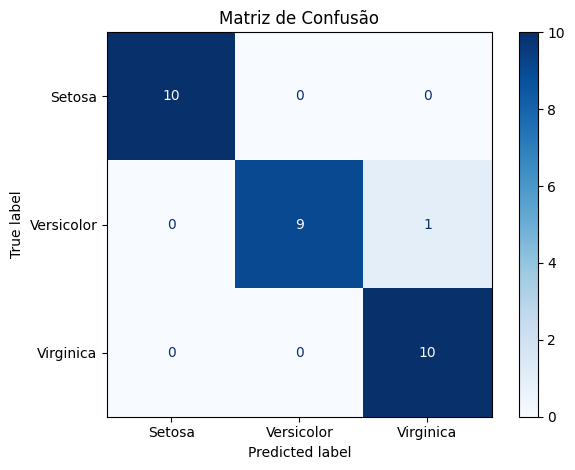

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Setosa", "Versicolor", "Virginica"])

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

#### **Métricas**

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Setosa", "Versicolor", "Virginica"]))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

